In [38]:
import numpy as np

In [76]:
X = np.array([[-1, -1], [-1, 1], [1, -1], [1, 1]])
z = np.array([[-1], [1], [1], [1]])

print(X.shape)

(4, 2)


In [77]:
def sigmoid(y):
    return 2.0/(1+np.exp(-y)) - 1.0

In [78]:
sigmoid(np.array([0, 1, 2]))

array([0.        , 0.46211716, 0.76159416])

In [79]:
def sigmoid_derivative(a):
    s = sigmoid(a)
    return 0.5 * (1-s) * (1+s)

In [80]:
np.random.seed(1000)
w = np.random.randn(2, 1)
b = np.zeros((1, 1))

print(w, w.shape)
print(b, b.shape)

[[-0.8044583 ]
 [ 0.32093155]] (2, 1)
[[0.]] (1, 1)


In [81]:
layer0 = X
y = np.dot(X, w) + b
layer1 = sigmoid(y)
print(y, y.shape)
print(np.dot(X, w))
print(layer1)

[[ 0.48352676]
 [ 1.12538985]
 [-1.12538985]
 [-0.48352676]] (4, 1)
[[ 0.48352676]
 [ 1.12538985]
 [-1.12538985]
 [-0.48352676]]
[[ 0.23716064]
 [ 0.50997422]
 [-0.50997422]
 [-0.23716064]]


In [82]:
def forward_compute(X, w, b):
    layer0 = X
    y = np.dot(X, w) + b
    layer1 = sigmoid(y)
    return layer0, layer1

In [83]:
np.dot(X, w), X.shape, w.shape

(array([[ 0.48352676],
        [ 1.12538985],
        [-1.12538985],
        [-0.48352676]]),
 (4, 2),
 (2, 1))

In [84]:
learning_rate = 0.1
layer0, layer1 = forward_compute(X, w, b)

decision = (layer1 >= 0.5)
error = np.sum(np.abs(decision-z))
loss = np.sum(np.abs(layer1 - z))
print(error, loss, layer1.T)
# if error == 0: break

layer1_error = layer1 - z
layer1_delta = layer1_error * sigmoid_derivative(layer1)

print(layer1_error)
print(layer1_delta)

3 4.47432128157507 [[ 0.23716064  0.50997422 -0.50997422 -0.23716064]]
[[ 1.23716064]
 [-0.49002578]
 [-1.50997422]
 [-1.23716064]]
[[ 0.60996317]
 [-0.22974844]
 [-0.70795097]
 [-0.60996317]]


In [85]:
print(X.T)
print(X.T.shape, layer1_delta.shape)
print(len(X))

[[-1 -1  1  1]
 [-1  1 -1  1]]
(2, 4) (4, 1)
4


In [86]:
learning_rate = 0.1
for epoch in range(1000):
    layer0, layer1 = forward_compute(X, w, b)

    decision = (layer1 >= 0.5)
    error = np.sum(np.abs(decision-z))
    loss = np.sum(np.abs(layer1 - z))
    print(epoch, error, loss, layer1.T)
    if error == 0: break

    layer1_error = layer1 - z
    layer1_delta = layer1_error * sigmoid_derivative(layer1)

    dw = np.dot(X.T, layer1_delta) / len(X)
    db = np.sum(layer1_delta) / len(X)

    w -= learning_rate * dw
    b -= learning_rate * db

0 3 4.47432128157507 [[ 0.23716064  0.50997422 -0.50997422 -0.23716064]]
1 3 4.398743244164938 [[ 0.21936267  0.50980119 -0.49224474 -0.19693702]]
2 3 4.32341578849316 [[ 0.20183437  0.50958955 -0.47434502 -0.15682594]]
3 3 4.248583319307009 [[ 0.18460046  0.50933661 -0.45630967 -0.1170098 ]]
4 3 4.17447283022238 [[ 0.16768223  0.50904068 -0.43817331 -0.07765796]]
5 3 4.101290418395967 [[ 0.1510975   0.50870103 -0.41997018 -0.03892378]]
6 3 4.029218849874559 [[ 0.13486053  0.50831798 -0.40173368 -0.00094261]]
7 3 3.9584161786477567 [[ 0.11898221  0.50789274 -0.38349611  0.0361694 ]]
8 3 3.889015347087032 [[ 0.10347016  0.50742741 -0.3652883   0.0723157 ]]
9 3 3.8211246394463556 [[ 0.08832899  0.50692486 -0.34713947  0.10741896]]
10 3 3.7548288261561242 [[ 0.07356058  0.50638861 -0.32907701  0.14142015]]
11 3 3.690190823782242 [[ 0.05916437  0.50582269 -0.3111264   0.17427726]]
12 3 3.6272537001497387 [[ 0.04513768  0.50523155 -0.29331116  0.20596359]]
13 3 3.5660428713254406 [[ 0.03147

In [87]:
w, b

(array([[3.02712441],
        [3.02722208]]),
 array([[3.02719761]]))

In [88]:
inputs, hiddens, outputs = 2, 4, 1
W1 = np.random.randn(inputs, hiddens) + 0.5
W2 = np.random.randn(hiddens, outputs) + 0.5
b1 = np.zeros(hiddens)
b2 = np.zeros(outputs)

In [89]:
# W1 = np.array([[1, 1], [-1, -1]], dtype=np.float32)
# W2 = np.array([[1], [1]], dtype=np.float32)
# b1 = np.array([0, 2], dtype=np.float32)
# b2 = np.array([-0.5], dtype=np.float32)
print(W1, W2, b1, b2)

[[0.47451712 1.14432383 0.19920333 0.88947455]
 [0.3925627  0.02001692 1.0950355  0.03533247]] [[ 1.16728131]
 [-0.30611561]
 [-0.69606983]
 [ 0.09403984]] [0. 0. 0. 0.] [0.]


In [90]:
def prediction(X, W1, W2, b1, b2):
    layer0 = X
    y1 = np.dot(X, W1) + b1
    layer1 = sigmoid(y1)
    y2 = np.dot(layer1, W2) + b2
    layer2 = sigmoid(y2)
    return layer0, layer1, layer2

## Loss = MSE

In [91]:
lossArray = []
learning_rate = 5
for epoch in range(10000):
    # prediction
    layer0, layer1, layer2 = prediction(X, W1, W2, b1, b2)
    z_2_hat = layer2

    # check break condition
    decision = z_2_hat.copy()
    decision[decision>=0] = 1
    decision[decision<0] = -1
    error = np.sum(np.abs(decision-z))
    loss = np.sum(np.abs(z_2_hat-z))
    lossArray.append(loss)
    print(epoch, error, loss, z_2_hat.T)
    # if error == 0: break 
    # 요거 break넣어주고 안넣어주고 따라 그래프 형태가 좀 바뀜

    # Backpropagation
    layer2_error = layer2 - z
    layer2_delta = layer2_error * sigmoid_derivative(layer2)
    dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
    db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)

    layer1_error = np.dot(layer2_delta, W2.T)
    layer1_delta = layer1_error * sigmoid_derivative(layer1)
    dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
    db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)

    # Update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

0 6.0 4.039841967630085 [[ 0.01992098 -0.11063548  0.11063548 -0.01992098]]
1 0.0 1.51347260506906 [[-0.14549812  0.6396767   0.78303087  0.91832171]]
2 0.0 1.026038841377786 [[-0.67760364  0.60535802  0.73311476  0.95788474]]
3 0.0 0.6859657900212923 [[-0.72657357  0.79262942  0.81556692  0.97926429]]
4 0.0 0.5149314337245474 [[-0.80085943  0.83786686  0.85909124  0.98725105]]
5 0.0 0.4049876706653459 [[-0.84356732  0.87117478  0.88894818  0.99132205]]
6 0.0 0.3305473041764897 [[-0.87215847  0.89430217  0.9093369   0.99365515]]
7 0.0 0.27747714679824054 [[-0.89251372  0.91097374  0.92391473  0.99512065]]
8 0.0 0.2380348043568934 [[-0.90765229  0.92344738  0.93475989  0.99610564]]
9 0.0 0.2077273715568957 [[-0.91929866  0.93307704  0.94309442  0.99680251]]
10 0.0 0.18380147736127495 [[-0.92850461  0.94070601  0.94967222  0.99731567]]
11 0.0 0.16448892497521306 [[-0.93594479  0.94688124  0.95497921  0.99770584]]
12 0.0 0.14860830543116288 [[-0.94206997  0.95197071  0.9593407   0.9980103

In [92]:
len(lossArray)

10000

In [93]:
import matplotlib.pyplot as plt

In [94]:
lossArray = np.array(lossArray)
print(lossArray.shape, type(lossArray))

(10000,) <class 'numpy.ndarray'>


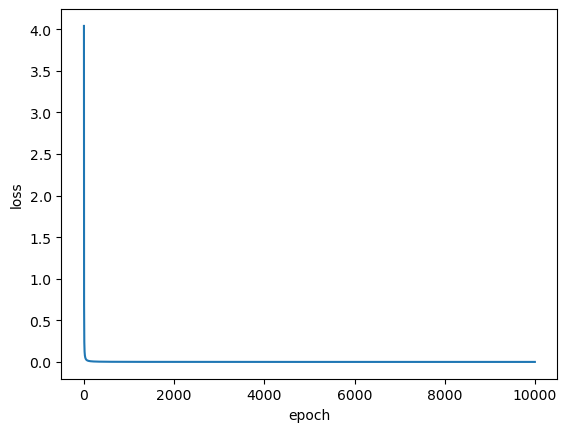

In [95]:
plt.plot(lossArray)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

### fit 이란 이름의 함수화

In [96]:
def fit(X, W1, W2, b1, b2, z, it_max=60000):
    lossArray = []
    learning_rate = 5
    for epoch in range(it_max):
        # prediction
        layer0, layer1, layer2 = prediction(X, W1, W2, b1, b2)
        z_2_hat = layer2
    
        # check break condition
        decision = z_2_hat.copy()
        decision[decision>=0] = 1
        decision[decision<0] = -1
        error = np.sum(np.abs(decision-z))
        loss = np.sum(np.abs(z_2_hat-z))
        lossArray.append(loss)
        print(epoch, error, loss, z_2_hat.T)
        #if error == 0: break 
        
        # Backpropagation
        layer2_error = layer2 - z
        layer2_delta = layer2_error * sigmoid_derivative(layer2)
        dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
        db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)
    
        layer1_error = np.dot(layer2_delta, W2.T)
        layer1_delta = layer1_error * sigmoid_derivative(layer1)
        dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
        db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)
    
        # Update
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    return W1, W2, b1, b2, np.array(lossArray), decision

In [97]:
it_max = 10000
W1_out, W2_out, b1_out, b2_out, lossArray, decision = fit(X, W1, W2, b1, b2, z, it_max)

0 0.0 8.361585499361279e-05 [[-0.99996517  0.99997533  0.9999761   0.99999979]]
1 0.0 8.360698774023678e-05 [[-0.99996517  0.99997533  0.9999761   0.99999979]]
2 0.0 8.35981223213933e-05 [[-0.99996518  0.99997534  0.9999761   0.99999979]]
3 0.0 8.35892587378595e-05 [[-0.99996518  0.99997534  0.9999761   0.99999979]]
4 0.0 8.358039698841413e-05 [[-0.99996518  0.99997534  0.99997611  0.99999979]]
5 0.0 8.357153707250209e-05 [[-0.99996519  0.99997535  0.99997611  0.99999979]]
6 0.0 8.356267899034542e-05 [[-0.99996519  0.99997535  0.99997611  0.99999979]]
7 0.0 8.355382273950163e-05 [[-0.99996519  0.99997535  0.99997611  0.99999979]]
8 0.0 8.354496832085889e-05 [[-0.9999652   0.99997535  0.99997612  0.99999979]]
9 0.0 8.353611573341801e-05 [[-0.9999652   0.99997536  0.99997612  0.99999979]]
10 0.0 8.352726497740104e-05 [[-0.99996521  0.99997536  0.99997612  0.99999979]]
11 0.0 8.35184160514757e-05 [[-0.99996521  0.99997536  0.99997612  0.99999979]]
12 0.0 8.350956895497585e-05 [[-0.9999652

In [98]:
import matplotlib.pyplot as plt

In [99]:
lossArray

array([8.36158550e-05, 8.36069877e-05, 8.35981223e-05, ...,
       4.01885399e-05, 4.01864218e-05, 4.01843038e-05], shape=(10000,))

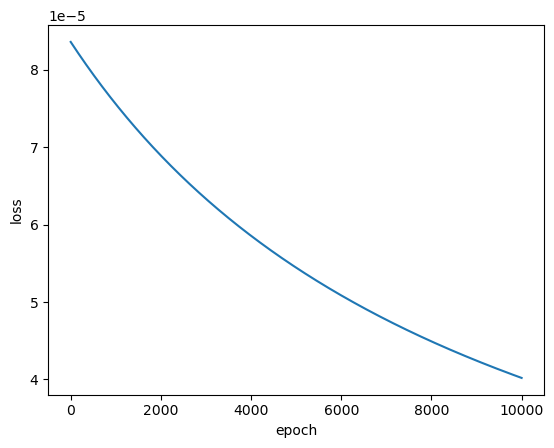

In [100]:
plt.plot(lossArray)
plt.xlabel("epoch")
plt.ylabel("loss")
# plt.ylim(1.2)
# 요거는 표시 범위임
plt.show()

## 2 hidden layers

In [101]:
inputs, hiddens1, hiddens2, outputs = 2, 3, 3, 1
W1 = np.random.randn(inputs, hiddens1)
W2 = np.random.randn(hiddens1, hiddens2)
W3 = np.random.randn(hiddens2, outputs)
b1 = np.zeros(hiddens1)
b2 = np.zeros(hiddens2)
b3 = np.zeros(outputs)

In [102]:
def prediction(X, W1, W2, W3, b1, b2, b3):
    layer0 = X
    y1 = np.dot(layer0, W1) + b1
    layer1 = sigmoid(y1)
    y2 = np.dot(layer1, W2) + b2
    layer2 = sigmoid(y2)
    y3 = np.dot(layer2, W3) + b3
    layer3 = sigmoid(y3)
    return layer0, layer1, layer2, layer3

In [109]:
learning_rate = 1.5
for epoch in range(10000):
    # prediction
    layer0, layer1, layer2, layer3 = prediction(X, W1, W2, W3, b1, b2, b3)
    z_3_hat = layer3

    # check break condition
    decision = z_3_hat.copy()
    decision[decision>=0] = 1
    decision[decision<0] = -1
    error = np.sum(np.abs(decision-z))
    print(epoch, error, z_3_hat.T)
    if error == 0:
        break

    # Backpropagation
    layer3_error = layer3 - z
    layer3_delta = layer3_error * sigmoid_derivative(layer3)
    dW3 = np.dot(layer2.T, layer3_delta) / len(layer3_delta)
    db3 = np.sum(layer3_delta, axis=0) / len(layer3_delta)

    layer2_error = np.dot(layer3_delta, W3.T)
    layer2_delta = layer2_error * sigmoid_derivative(layer2)
    dW2 = np.dot(layer1.T, layer2_delta) / len(layer2_delta)
    db2 = np.sum(layer2_delta, axis=0) / len(layer2_delta)

    layer1_error = np.dot(layer2_delta, W2.T)
    layer1_delta = layer1_error * sigmoid_derivative(layer1)
    dW1 = np.dot(layer0.T, layer1_delta) / len(layer1_delta)
    db1 = np.sum(layer1_delta, axis=0) / len(layer1_delta)

    # Update
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

0 0.0 [[-0.10325982  0.54971808  0.03603921  0.61475645]]
